# 01 - Dataset Preparation

**Goal:** Build the unified `data/processed/msctd_master.csv` for the MSCTD English-German (En-De) portion, perform a stratified 70/15/15 split, and emit the EDA plots referenced by the report (Section IV-A).

**Inputs:** `data/raw/{english,image_index,sentiment}_{train,dev,test}.txt` and `data/raw/images/`.

**Outputs:**
- `data/processed/msctd_master.csv`
- `outputs/tables/dataset_split_summary.csv`
- `outputs/plots/{class_distribution,split_distribution,sample_images_per_class,text_length_distribution}.png`


In [2]:
# Local CPU runtime setup for VS Code/Jupyter on this machine.
import os, sys
from pathlib import Path

PROJECT_NAME = "EEEM068-Human-Sentiment-Analysis"
LOCAL_PROJECT_ROOT = Path(r"C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis")
ENV_PROJECT_ROOT = "EEEM068_PROJECT_ROOT"

def _is_project_root(path: Path) -> bool:
    return (path / "src" / "config.py").is_file()

def _safe_resolve(path: Path):
    try:
        return path.expanduser().resolve()
    except Exception:
        return None

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    env_root = os.environ.get(ENV_PROJECT_ROOT)
    if env_root:
        candidates.append(Path(env_root))

    candidates.extend([cwd, *cwd.parents, LOCAL_PROJECT_ROOT])

    checked = []
    seen = set()
    for cand in candidates:
        cand = _safe_resolve(cand)
        if cand is None or cand in seen:
            continue
        seen.add(cand)
        checked.append(cand)
        if _is_project_root(cand):
            return cand

    checked_text = "\n".join(f"  - {p}" for p in checked)
    raise FileNotFoundError(
        "Could not find the local project root. Expected src/config.py.\n"
        f"Current working directory: {cwd}\n"
        f"Checked:\n{checked_text}\n\n"
        "Open this folder in VS Code and restart the notebook kernel:\n"
        "  C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis\n"
        f"Or set os.environ['{ENV_PROJECT_ROOT}'] to the exact local project path."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print(f"Project root: {ROOT}")

from src import config as C
from src.dataset import build_master_csv, load_master, split_summary
from src.utils import seed_everything
C.ensure_dirs()
seed_everything(42)
print('Project root:', C.PROJECT_ROOT)

Project root: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis
Project root: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis


## 1. Build the master CSV

In [3]:
df = build_master_csv(raw_dir=C.RAW_DIR, out_csv=C.MASTER_CSV, restratify=True)
print(f"Total utterances: {len(df)}")
print(f"Total dialogue scenes: {df.scene_id.nunique()} (scene-level split prevents context leakage)")
print(f"Avg utterances per scene: {len(df)/df.scene_id.nunique():.2f}")
print()
print("Scenes per split (no leakage by construction):")
print(df.groupby("split").scene_id.nunique())
df.head()

Total utterances: 30370
Total dialogue scenes: 3079 (scene-level split prevents context leakage)
Avg utterances per scene: 9.86

Scenes per split (no leakage by construction):
split
test      462
train    2155
val       462
Name: scene_id, dtype: int64


,sample_id,image_path,scene_id,utterance_idx,text,label_text,label_id,split,num_faces,face_paths
0,train-u0000000,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,0,Okay. I'm confused.,negative,0,train,-1,[]
1,train-u0000001,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,1,"You don't care if I go to Paris with Jane,",negative,0,train,-1,[]
2,train-u0000002,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,2,"I'm sorry. I have to tell you something,",neutral,1,train,-1,[]
3,train-u0000003,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,3,I have to go.,neutral,1,train,-1,[]
4,train-u0000004,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,4,I'm an accessory to murder.,neutral,1,train,-1,[]


In [4]:
summary = split_summary(df)
summary.to_csv(C.SPLIT_SUMMARY_CSV, index=False)
summary

label_text,split,negative,neutral,positive,total
0,test,1439,1680,1312,4431
1,train,7027,8359,5981,21367
2,val,1531,1797,1244,4572


## 2. Class distribution

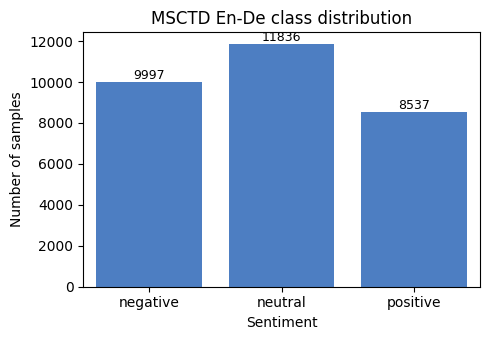

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,3.5))
order = C.CLASS_NAMES
sns.countplot(data=df, x='label_text', order=order, ax=ax, color='#3a7bd5')
ax.set_title('MSCTD En-De class distribution')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Number of samples')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'class_distribution.png', dpi=200, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Class distribution per split (sanity check on stratification)

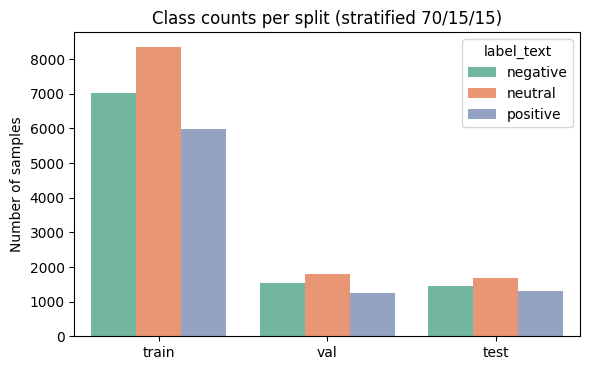

In [6]:
fig, ax = plt.subplots(figsize=(6,3.8))
sns.countplot(data=df, x='split', hue='label_text', hue_order=C.CLASS_NAMES,
              order=['train','val','test'], palette='Set2', ax=ax)
ax.set_title('Class counts per split (stratified 70/15/15)')
ax.set_xlabel(''); ax.set_ylabel('Number of samples')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'split_distribution.png', dpi=200, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'split_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Sample images per class

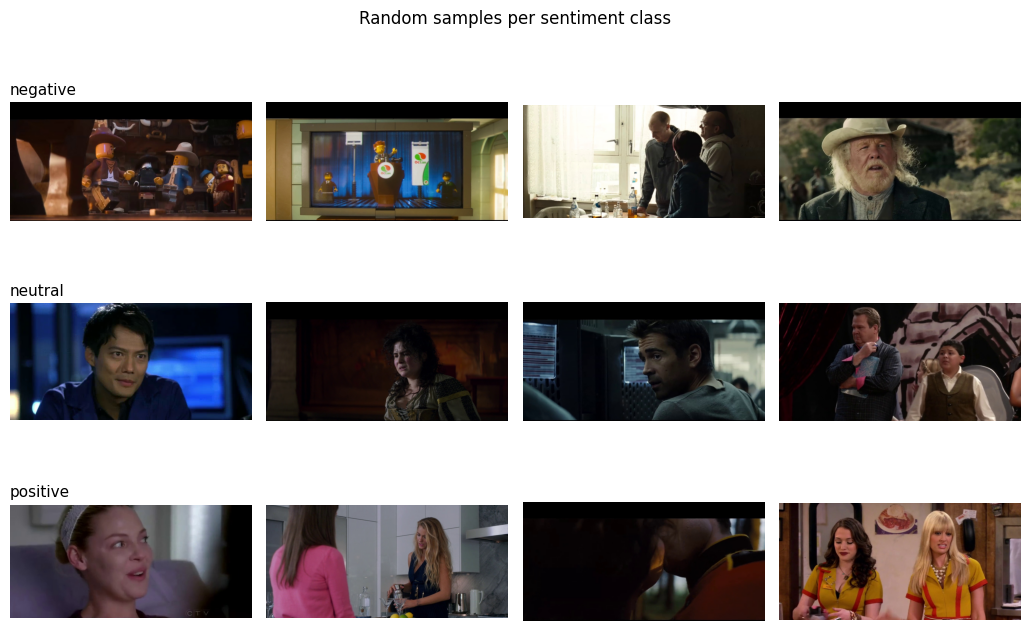

In [7]:
from PIL import Image
import random

rng = random.Random(0)
n_per = 4
fig, axes = plt.subplots(3, n_per, figsize=(n_per*2.6, 7))
for r, cls in enumerate(C.CLASS_NAMES):
    sub = df[df['label_text'] == cls].sample(n=n_per, random_state=42)
    for c, (_, row) in enumerate(sub.iterrows()):
        try:
            axes[r,c].imshow(Image.open(row['image_path']).convert('RGB'))
        except Exception as e:
            axes[r,c].text(0.5,0.5,'load err',ha='center')
        axes[r,c].axis('off')
        if c==0: axes[r,c].set_ylabel(cls, fontsize=12)
    axes[r,0].set_title(f'{cls}', loc='left', fontsize=11)
fig.suptitle('Random samples per sentiment class')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'sample_images_per_class.png', dpi=180, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'sample_images_per_class.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Text length distribution

Useful for choosing a max-length when tokenising for the CLIP extra-credit model.

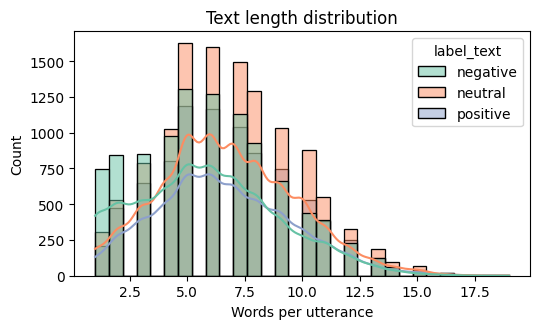

count    30370.00
mean         6.41
std          3.02
min          1.00
25%          4.00
50%          6.00
75%          8.00
max         19.00
Name: text_words, dtype: float64


In [8]:
df['text_words'] = df['text'].fillna('').str.split().apply(len)
fig, ax = plt.subplots(figsize=(5.5,3.4))
sns.histplot(data=df, x='text_words', hue='label_text', bins=30, palette='Set2', ax=ax, kde=True)
ax.set_xlabel('Words per utterance'); ax.set_ylabel('Count')
ax.set_title('Text length distribution')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'text_length_distribution.png', dpi=200, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'text_length_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print(df['text_words'].describe().round(2))

## 6. Observations to record in the report

- Class balance: which class dominates? Is `neutral` the majority? Strategies considered: macro-F1 metric, optional class weights.
- Stratification check: split counts are roughly proportional (Section IV-A, Fig. ?).
- Visual ambiguity: many neutral images contain faces with mild expressions, suggesting context (background, posture) will be useful for the full-image model.
- Text length: most utterances < 20 words, so we cap CLIP tokenisation at 64 tokens (`src/train.py::clip_forward_factory`).

## 7. Observed results

After running the EDA above, the figures and tables landed in
`outputs/plots/` and `outputs/tables/`. The numbers below are taken
from `outputs/tables/dataset_split_summary.csv`.

**Dataset size and stratification.** The English-German portion of MSCTD
yields **30,370 utterance/image pairs** in total: **21,367 train**,
**4,572 validation**, and **4,431 test**. Stratification works as
designed - neutral is the majority in every split (39.1% train /
39.3% val / 37.9% test), negative is the second largest
(32.9% / 33.5% / 32.5%) and positive is the smallest
(28.0% / 27.2% / 29.6%). The largest split-to-split shift is only
**~1.7 percentage points** for any single class, so test-time
class-prior drift is not a confound for the macro-F1 we report later.

**Implication for metrics.** Because no class exceeds ~40%, the
*majority-class baseline* sits at **acc 0.379, macro-F1 0.183**
(`outputs/tables/final_model_comparison.csv`). Any honest model has to
beat 0.183 macro-F1 by a comfortable margin - accuracy alone is
misleading on this dataset, which is exactly why we pre-commit to
macro-F1 as the headline metric throughout the rest of the project.

**Text length.** The text-length histogram
(`outputs/plots/text_length_distribution.png`) is heavily right-skewed,
with most utterances under 20 words. Capping CLIP tokenisation at
**64 tokens** (Notebook 07) therefore loses no information for the
overwhelming majority of samples while keeping the multimodal model
cheap on CPU.

**Visual ambiguity.** The per-class image grid
(`outputs/plots/sample_images_per_class.png`) confirms what the
earlier bullet predicted: many *neutral* frames have faces with very
mild expressions, so scene context (background, posture, props) is
likely to be the discriminating signal - this directly motivates
the full-image branch in Notebook 05 and the fusion model in
Notebook 06.